# Song Popularity Prediction

In this notebook we will get familiar with the spotify record dataset provided by Kaggle<br><br>

**Dataset Used:-** Spotify Tracks Dataset

**1. Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Loading the dataset**

In [3]:
df = pd.read_csv('../data/raw/spotify_tracks.csv')
df.sample(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
94481,94481,4PwkiQyE09iOcKameCkQAF,Moxas,Love Curse,Love Curse,57,154285,True,0.757,0.499,...,-10.666,0,0.0553,0.667,0.000003,0.1090,0.550,112.051,4,sad
10822,10822,6SCLDZSPxSSHxvViSV8NgE,The Prodigy;Wonder,Voodoo People / Out of Space,Voodoo People - Wonder Remix,12,298080,False,0.778,0.610,...,-8.578,1,0.0593,0.130,0.002300,0.1650,0.586,139.881,4,breakbeat
68826,68826,3GIRzF4WLdmjaqgoFFsfXV,LIT killah,Una Vez Mas,Una Vez Mas,43,214347,False,0.782,0.438,...,-7.574,1,0.0792,0.220,0.000000,0.0909,0.428,121.990,4,latino
16200,16200,3n2BgDsO63JKpqftVR2Ysc,A. Kanyakumari;Janardan Mitta,Prashantham,Raga - Neelambari,43,122640,False,0.273,0.080,...,-13.988,1,0.0422,0.986,0.253000,0.0628,0.184,88.252,4,classical
55223,55223,7ttlemwytO21npSmLKqTBg,Pritam;Shreya Ghoshal;Nikhil Paul George,Barfi! (Original Motion Picture Soundtrack),Aashiyan,57,236373,False,0.829,0.622,...,-7.293,1,0.0518,0.293,0.000003,0.1670,0.775,131.971,4,indian


**3. Basic Analysis of the dataset**

In [5]:
df.shape

(114000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [9]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [12]:
df['popularity'].describe()

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Since the target column -'Popularity' have values ranging from 0 to 100 seeing value count will not help much .<br>
Hence we will plot the distribution by binning the values in bin of 5 (0-5, 5-10 ...)

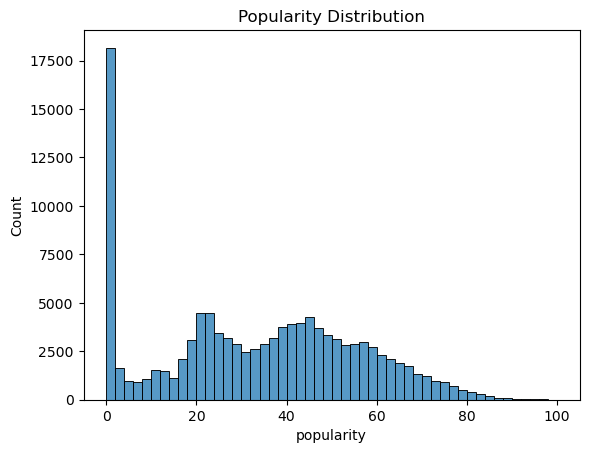

In [16]:
sns.histplot(df['popularity'], bins=50)
plt.title("Popularity Distribution")
plt.show()
